# NSynth Melody Match Task

This notebook evaluates models on a zero-shot melody match task using NSynth validation clips. The task tests whether models can identify when two note sequences follow the same melodic pattern (same interval sequence) versus different patterns, even when transposed to different pitch ranges.

In [8]:
import json
import math
import random
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Tuple
import sys

import torch
import torchaudio
import torch.nn.functional as F
import pandas as pd

from IPython.display import Audio, display

%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import seaborn as sns
import numpy as np

from tqdm.auto import tqdm
# Ensure tqdm works in notebooks
try:
    from IPython import get_ipython
    if 'IPKernelApp' in get_ipython().config:
        tqdm.pandas()  # Enable pandas integration if needed
except:
    pass

from lightning_scripts.nsynth_triplet_dataset import NsynthTripletDataset
from lightning_scripts.byola_lightning_module  import BYOLAModule

# Import figure_utils for standardized plotting
sys.path.append('../')
import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    get_model_groups,
    model_label,
    plot_grouped_bars,
)
import yaml

## Load pretrained models

In [2]:
# Device and target sample rate for generated clips
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SR = 20_000

# Load pretrained models
import importlib
from lightning_scripts.utils import model_build_utils
importlib.reload(model_build_utils)
from lightning_scripts.utils.model_build_utils import get_model

# SSL models with different lambda values
ssl_lambda_0_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01.yaml")
ssl_lambda_1_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01.yaml")
ssl_lambda_2_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01.yaml")
ssl_lambda_3_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01.yaml")
ssl_lambda_4_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01.yaml")
ssl_lambda_5_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01.yaml")

# Scaled SSL models
ssl_scaled_lambda_0_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only.yaml")
ssl_scaled_lambda_5_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only.yaml")

# Supervised models
word_config = Path("model_configs/supervised_models/word_kell2018_MatchedDataset_LARS.yaml")
audioset_config = Path("model_configs/supervised_models/audioset_kell2018_MatchedDataset_LARS.yaml")
multitask_config = Path("model_configs/supervised_models/kell2018_word_speaker_audioset_MatchedDataset_LARS.yaml")
unbal_audioset_config = Path("model_configs/supervised_models/kell2018_audioset_unbalanced_supervised.yaml")

# BYOL-A config
byola_config = "byol-a/config.yaml"
byola_config = yaml.load(open(byola_config, 'r'), Loader=yaml.FullLoader)
# Load models
models = {}
model_name_map = {}  # Maps internal name to standardized name

# SSL models
models["ssl_λ=0.0"] = get_model(ssl_lambda_0_config, layer_out="relu4")
model_name_map["ssl_λ=0.0"] = "CochDNN9 ssl λ=0.0"

models["ssl_λ=0.1"] = get_model(ssl_lambda_1_config, layer_out="relu4")
model_name_map["ssl_λ=0.1"] = "CochDNN9 ssl λ=0.1"

models["ssl_λ=0.2"] = get_model(ssl_lambda_2_config, layer_out="relu4")
model_name_map["ssl_λ=0.2"] = "CochDNN9 ssl λ=0.2"

models["ssl_λ=0.3"] = get_model(ssl_lambda_3_config, layer_out="relu4")
model_name_map["ssl_λ=0.3"] = "CochDNN9 ssl λ=0.3"

models["ssl_λ=0.4"] = get_model(ssl_lambda_4_config, layer_out="relu4")
model_name_map["ssl_λ=0.4"] = "CochDNN9 ssl λ=0.4"

models["ssl_λ=0.5"] = get_model(ssl_lambda_5_config, layer_out="relu4")
model_name_map["ssl_λ=0.5"] = "CochDNN9 ssl λ=0.5"

# Scaled SSL models
models["scaled_ssl_λ=0.0"] = get_model(ssl_scaled_lambda_0_config, layer_out="relu4")
model_name_map["scaled_ssl_λ=0.0"] = "CochDNN9 scaled ssl λ=0.0"

models["scaled_ssl_λ=0.5"] = get_model(ssl_scaled_lambda_5_config, layer_out="relu4")
model_name_map["scaled_ssl_λ=0.5"] = "CochDNN9 scaled ssl λ=0.5"

# Supervised models
models["word"] = get_model(word_config, supervised=True, layer_out="relu4")
model_name_map["word"] = "CochDNN9 supervised word"

models["audioset"] = get_model(audioset_config, supervised=True, layer_out="relu4")
model_name_map["audioset"] = "CochDNN9 supervised audioset"

models["multitask"] = get_model(multitask_config, supervised=True, layer_out="relu4")
model_name_map["multitask"] = "CochDNN9 supervised multi-task"

models["unbal_audioset"] = get_model(unbal_audioset_config, supervised=True, layer_out="relu4")
model_name_map["unbal_audioset"] = "CochDNN9 scaled supervised"

models["byol-a"] = BYOLAModule(byola_config).cuda().eval()
model_name_map["byol-a"] = "BYOL-A"

# push all models to device
for model in models.values():
    model.to(DEVICE)


/mnt/ceph/users/igriffith/projects/cochdnn/byol-a/byol_a/models.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = state_dict or torch.load(weight_file, map_l

In [3]:
## Setup standardized plotting colors and model names
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

# Get model groups for legend handling
supervised_names, ssl_names, scaled_ssl_names, byol_names = get_model_groups(hue_order)

# Normalize model names in our map
normalized_model_name_map = {k: normalize_model_name(v) for k, v in model_name_map.items()}

In [4]:
def encode_audio(model, audio_batch: torch.Tensor) -> torch.Tensor:
    model.eval()
    with torch.no_grad():
        z = model(audio_batch)
        if z.ndim > 2:
            z = z.flatten(start_dim=1)
    return z


def distance_metrics_on_triplet(model, clips: Dict[str, torch.Tensor], sr: int) -> Dict[str, float]:
    """Compute simple L2 distances between anchor-positive and anchor-negative."""
    waves = {}
    for k, v in clips.items():
        w = v
        # BYOL-A wrapper handles its own resampling, others need 20kHz
        # Check if model has byola_sr attribute (BYOL-A wrapper)
        if isinstance(model, BYOLAModule):
            w = torchaudio.functional.resample(w.unsqueeze(0), sr, 16_000).squeeze(0)
        waves[k] = w.to(DEVICE)

    # Encode each example separately -- do not pair batch
    if isinstance(model, BYOLAModule):
        anchor_batch = waves["anchor"].unsqueeze(0)
        positive_batch = waves["positive"].unsqueeze(0)
        negative_batch = waves["negative"].unsqueeze(0)
    else:
        anchor_batch = waves["anchor"].unsqueeze(0).unsqueeze(1)
        positive_batch = waves["positive"].unsqueeze(0).unsqueeze(1)
        negative_batch = waves["negative"].unsqueeze(0).unsqueeze(1)

    z_anchor = encode_audio(model, anchor_batch)
    z_pos = encode_audio(model, positive_batch)
    z_neg = encode_audio(model, negative_batch)

    pos_l2 = torch.norm(z_anchor - z_pos, p=2).item()
    neg_l2 = torch.norm(z_anchor - z_neg, p=2).item()

    return {
        "pos_l2": pos_l2,
        "neg_l2": neg_l2,
        "judgement_pos_lt_neg": int(pos_l2 < neg_l2),
    }

## Melody Match Task

This task tests whether models can identify when two note sequences follow the same melodic pattern. Anchor and positive share the same interval sequence (melody), while negative uses a different interval sequence, even though all three are transposed to different pitch ranges.

In [26]:
# Instantiate dataset and dataloader
melody_df = NsynthTripletDataset(n_examples=5000, seed=42, min_midi=30, max_midi=90, experiment_type="melody_match", balance_eval=True)

def nsynth_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

melody_loader = torch.utils.data.DataLoader(
    melody_df, batch_size=1, shuffle=False, collate_fn=nsynth_triplet_collate
)
print(f"Triplet dataset ready: {len(melody_df)} examples at target_sr={melody_df.target_sr}")


all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(melody_loader), total=len(melody_loader), desc="Evaluating triplets"):
    for name, model in tqdm(models.items(), desc="Evaluating models", leave=False):
        sr_val = int(sr)
        interval = triplet["anchor"]["interval"]
        negative_interval = triplet["negative"]["interval"]
        interval_diff = negative_interval - interval
        instrument = triplet["anchor"]["instrument"]

        metrics = distance_metrics_on_triplet(model, clips, sr_val)
        normalized_name = normalized_model_name_map.get(name, name)
        metrics.update({"model_name": normalized_name, "model_internal": name, "batch_idx": batch_idx, "interval": interval, "instrument": instrument, "negative_interval": negative_interval, "interval_diff": interval_diff})
        all_results.append(metrics)
    

melody_match_results_df = pd.DataFrame(all_results)
display(melody_match_results_df.head())

Triplet dataset ready: 4800 examples at target_sr=20000


Evaluating triplets:   0%|          | 0/4800 [00:00<?, ?it/s]

Evaluating models:   0%|          | 0/13 [00:00<?, ?it/s]

Evaluating models:   0%|          | 0/13 [00:00<?, ?it/s]

Evaluating models:   0%|          | 0/13 [00:00<?, ?it/s]

...

Evaluating models:   0%|          | 0/13 [00:00<?, ?it/s]

Evaluating models:   0%|          | 0/13 [00:00<?, ?it/s]

Evaluating models:   0%|          | 0/13 [00:00<?, ?it/s]

Evaluating models:   0%|          | 0/13 [00:00<?, ?it/s]

,pos_l2,neg_l2,judgement_pos_lt_neg,model_name,model_internal,batch_idx,interval,instrument,negative_interval,interval_diff
0,7.953719,8.128704,1,CochDNN9 ssl λ=0.0,ssl_λ=0.0,0,5,guitar_electronic_022,-5,-10
1,6.992491,8.186345,1,CochDNN9 ssl λ=0.1,ssl_λ=0.1,0,5,guitar_electronic_022,-5,-10
2,7.613668,8.950641,1,CochDNN9 ssl λ=0.2,ssl_λ=0.2,0,5,guitar_electronic_022,-5,-10
3,6.271279,7.683633,1,CochDNN9 ssl λ=0.3,ssl_λ=0.3,0,5,guitar_electronic_022,-5,-10
4,7.405902,10.285996,1,CochDNN9 ssl λ=0.4,ssl_λ=0.4,0,5,guitar_electronic_022,-5,-10


## Plot Results

In [27]:
# rename 'BYOL-A' to "byol-a"
melody_match_results_df['model_name'] = melody_match_results_df['model_name'].str.replace('BYOL-A', 'byol-a')


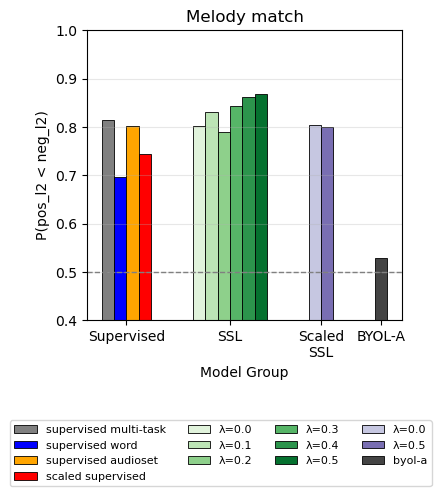

In [28]:
# Plot aggregate results using standardized plotting format
plot_df = melody_match_results_df[melody_match_results_df['model_name'].isin(hue_order)].copy()

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

handles, labels = plot_grouped_bars(
    ax,
    plot_df,
    value_col='judgement_pos_lt_neg',
    title='Melody match',
    ylabel='P(pos_l2 < neg_l2)',
    hue_order=hue_order,
    hue_dict=hue_dict,
)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylim(0.4, 1.0)
ax.grid(True, axis="y", alpha=0.3)

# Build legend
legend_handles = []
legend_labels = []
for handle, label in zip(handles, labels):
    legend_handles.append(handle)
    legend_labels.append(label)

# Ensure scaled SSL palette entries appear in legend, even if missing from data
for model in scaled_ssl_names:
    label = model_label(model)
    if label not in legend_labels:
        color = hue_dict.get(model, '#444444')
        legend_handles.append(Patch(facecolor=color, edgecolor='black'))
        legend_labels.append(label)

if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=4,
    )

plt.tight_layout()
plt.show()

## Load ResNet18 models from eval_dict and supervised models

In [ ]:
import pickle

# Load ResNet18 SSL models from eval_dict
eval_dict_path = Path("train_config_manifests/resnet18_barlow_equivariant_lmbda_search_eval_dict.pkl")
eval_dict = pickle.load(open(eval_dict_path, 'rb'))

# ResNet18 supervised models
resnet18_word_config = Path("model_configs/supervised_models/word_resnet18_MatchedDataset_LARS.yaml")
resnet18_audioset_config = Path("model_configs/supervised_models/audioset_resnet18_MatchedDataset_LARS.yaml")
resnet18_multitask_config = Path("model_configs/supervised_models/word_speaker_audioset_resnet18_MatchedDataset_shuffle_one_gpu_LARS.yaml")

# Load ResNet18 SSL models from eval_dict
resnet18_models = {}
resnet18_model_name_map = {}

for idx, config_path in eval_dict.items():
    config_path = Path(config_path)
    # Extract lambda value from config name for naming
    config_name = config_path.stem
    if 'eq_lmbda' in config_name:
        # Extract lambda value (format: eq_lmbda_5e-01 means 0.5)
        import re
        match = re.search(r'eq_lmbda_(\d+)e-(\d+)', config_name)
        if match:
            coeff = float(match.group(1))
            exp = float(match.group(2))
            lambda_val = coeff * (10 ** -exp)
            model_key = f"resnet18_ssl_λ={lambda_val}"
            resnet18_models[model_key] = get_model(config_path, layer_out="layer4")
            resnet18_model_name_map[model_key] = f"ResNet18 ssl λ={lambda_val}"
        else:
            # Fallback naming
            model_key = f"resnet18_ssl_{idx}"
            resnet18_models[model_key] = get_model(config_path, layer_out="layer4")
            resnet18_model_name_map[model_key] = f"ResNet18 ssl {config_name}"
    elif 'invariant_only' in config_name:
        model_key = "resnet18_ssl_invar"
        resnet18_models[model_key] = get_model(config_path, layer_out="layer4")
        resnet18_model_name_map[model_key] = "ResNet18 ssl invar"

# Load ResNet18 supervised models
resnet18_models["resnet18_word"] = get_model(resnet18_word_config, supervised=True, layer_out="layer4")
resnet18_model_name_map["resnet18_word"] = "ResNet18 supervised word"

resnet18_models["resnet18_audioset"] = get_model(resnet18_audioset_config, supervised=True, layer_out="layer4")
resnet18_model_name_map["resnet18_audioset"] = "ResNet18 supervised audioset"

resnet18_models["resnet18_multitask"] = get_model(resnet18_multitask_config, supervised=True, layer_out="layer4")
resnet18_model_name_map["resnet18_multitask"] = "ResNet18 supervised multi-task"

# Push all ResNet18 models to device
for model in resnet18_models.values():
    model.to(DEVICE)

print(f"Loaded {len(resnet18_models)} ResNet18 models")

## Evaluate ResNet18 models

In [ ]:
# Evaluate ResNet18 models on melody match task
resnet18_all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(melody_loader), total=len(melody_loader), desc="Evaluating ResNet18 triplets"):
    for name, model in tqdm(resnet18_models.items(), desc="Evaluating ResNet18 models", leave=False):
        sr_val = int(sr)
        interval = triplet["anchor"]["interval"]
        negative_interval = triplet["negative"]["interval"]
        interval_diff = negative_interval - interval
        instrument = triplet["anchor"]["instrument"]

        metrics = distance_metrics_on_triplet(model, clips, sr_val)
        normalized_name = normalize_model_name(resnet18_model_name_map.get(name, name))
        metrics.update({
            "model_name": normalized_name, 
            "model_internal": name, 
            "batch_idx": batch_idx, 
            "interval": interval, 
            "instrument": instrument, 
            "negative_interval": negative_interval, 
            "interval_diff": interval_diff
        })
        resnet18_all_results.append(metrics)
    

resnet18_melody_match_results_df = pd.DataFrame(resnet18_all_results)
display(resnet18_melody_match_results_df.head())

## Plot ResNet18 results

In [ ]:
# Plot ResNet18 aggregate results using standardized plotting format
resnet18_plot_df = resnet18_melody_match_results_df[resnet18_melody_match_results_df['model_name'].isin(hue_order)].copy()

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

handles, labels = plot_grouped_bars(
    ax,
    resnet18_plot_df,
    value_col='judgement_pos_lt_neg',
    title='Melody match (ResNet18)',
    ylabel='P(pos_l2 < neg_l2)',
    hue_order=hue_order,
    hue_dict=hue_dict,
)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylim(0.4, 1.0)
ax.grid(True, axis="y", alpha=0.3)

# Build legend
legend_handles = []
legend_labels = []
for handle, label in zip(handles, labels):
    legend_handles.append(handle)
    legend_labels.append(label)

# Ensure scaled SSL palette entries appear in legend, even if missing from data
for model in scaled_ssl_names:
    label = model_label(model)
    if label not in legend_labels:
        color = hue_dict.get(model, '#444444')
        legend_handles.append(Patch(facecolor=color, edgecolor='black'))
        legend_labels.append(label)

if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=4,
    )

plt.tight_layout()
plt.show()